In [2]:
import pandas as pd

# Define the file name as it appears in the Colab file explorer on the left.
# Based on your screenshot, the file is named 'sales.csv' or simply 'sales'.

try:
    # Attempting to load the dataset using the .csv extension
    df = pd.read_csv('sales.csv')
    print("Congratulations! Data has been successfully loaded. ✅")
    print("\n--- Displaying the First 5 Rows of the Dataset ---")
    display(df.head())

except Exception as e:
    # Fallback option: Attempting to load the file if it was uploaded without an extension
    try:
        df = pd.read_csv('sales')
        print("Data loaded successfully (without file extension). ✅")
        display(df.head())
    except Exception as secondary_error:
        print(f"Error: Could not load the file. Please ensure 'sales.csv' is uploaded to the Colab sidebar.")

Congratulations! Data has been successfully loaded. ✅

--- Displaying the First 5 Rows of the Dataset ---


,sale_id,branch,city,customer_type,gender,product_name,product_category,unit_price,quantity,tax,total_price,reward_points
0,1,A,New York,Member,Male,Shampoo,Personal Care,5.50,3,1.16,17.66,1
1,2,B,Los Angeles,Normal,Female,Notebook,Stationery,2.75,10,1.93,29.43,0
2,3,A,New York,Member,Female,Apple,Fruits,1.20,15,1.26,19.26,1
3,4,A,Chicago,Normal,Male,Detergent,Household,7.80,5,2.73,41.73,0
4,5,B,Los Angeles,Member,Female,Orange Juice,Beverages,3.50,7,1.72,26.22,2


In [3]:
# Check the structure of the data (Columns, Data Types, and Non-Null counts)
print("--- Data Structure ---")
df.info()

# Check for missing values in each column
print("\n--- Missing Values Count ---")
print(df.isnull().sum())

# Get a statistical summary of numerical columns (Price, Quantity, Total)
print("\n--- Summary Statistics ---")
display(df.describe())

--- Data Structure ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   sale_id           1000 non-null   int64  
 1   branch            1000 non-null   object 
 2   city              1000 non-null   object 
 3   customer_type     1000 non-null   object 
 4   gender            1000 non-null   object 
 5   product_name      1000 non-null   object 
 6   product_category  1000 non-null   object 
 7   unit_price        1000 non-null   float64
 8   quantity          1000 non-null   int64  
 9   tax               1000 non-null   float64
 10  total_price       1000 non-null   float64
 11  reward_points     1000 non-null   int64  
dtypes: float64(3), int64(3), object(6)
memory usage: 93.9+ KB

--- Missing Values Count ---
sale_id             0
branch              0
city                0
customer_type       0
gender              0
product_na

,sale_id,unit_price,quantity,tax,total_price,reward_points
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,10.836110,10.337000,7.758010,118.583900,6.057000
std,288.819436,5.775924,6.029908,6.538066,99.936441,9.350464
min,1.000000,1.020000,1.000000,0.080000,1.210000,0.000000
25%,250.750000,5.867500,5.000000,2.510000,38.380000,0.000000
50%,500.500000,10.615000,10.000000,5.870000,89.705000,0.000000
75%,750.250000,15.882500,16.000000,11.522500,176.072500,10.000000
max,1000.000000,20.980000,20.000000,28.390000,433.990000,43.000000


In [4]:
# 1. Total Revenue by City
city_revenue = df.groupby('city')['total_price'].sum().sort_values(ascending=False)
print("Total Revenue by City:\n", city_revenue)

# 2. Most Popular Product Categories
top_categories = df['product_category'].value_counts()
print("\nProduct Category Popularity:\n", top_categories)

# 3. Preferred Payment Method
payment_preference = df.groupby('gender')['total_price'].mean()
print("\nAverage Spend by Gender:\n", payment_preference)

Total Revenue by City:
 city
Chicago        42584.71
New York       40226.93
Los Angeles    35772.26
Name: total_price, dtype: float64

Product Category Popularity:
 product_category
Fruits           209
Personal Care    208
Stationery       198
Household        198
Beverages        187
Name: count, dtype: int64

Average Spend by Gender:
 gender
Female    114.969174
Male      121.815246
Name: total_price, dtype: float64


/tmp/ipykernel_320/24419130.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=city_revenue.index, y=city_revenue.values, palette='viridis')


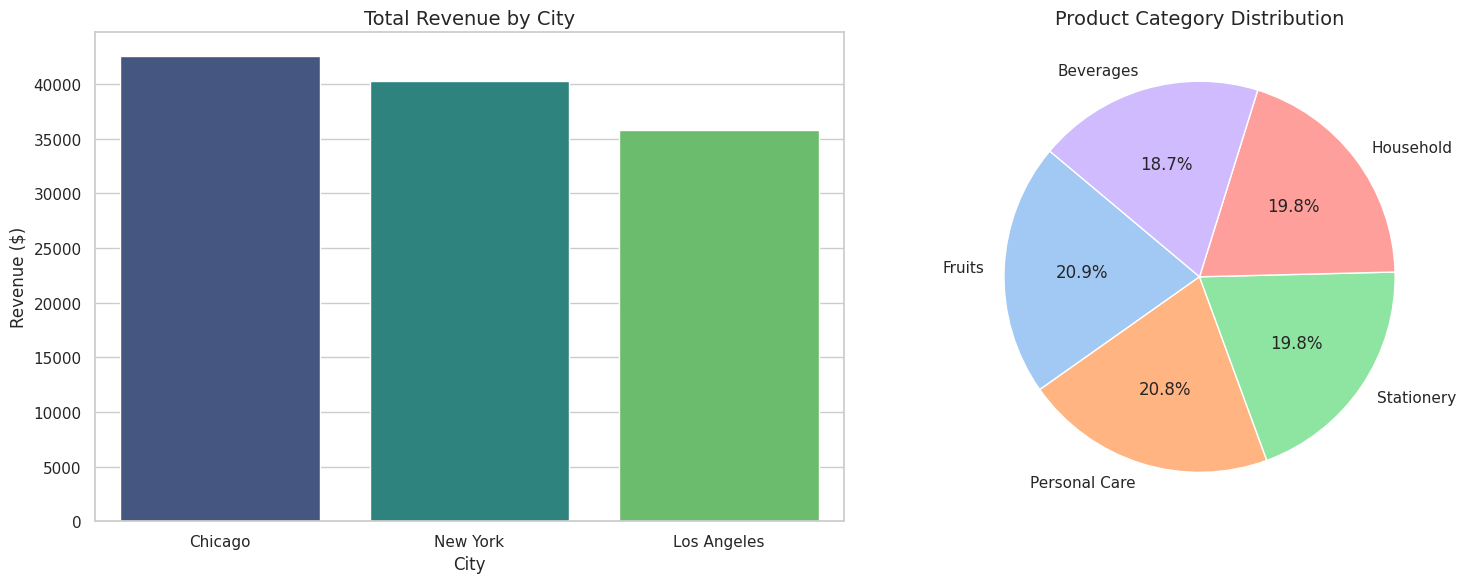

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a professional theme for the plots
sns.set_theme(style="whitegrid")

# Create a figure with two subplots (1 row, 2 columns)
plt.figure(figsize=(16, 6))

# Plot 1: Revenue by City (Bar Chart)
plt.subplot(1, 2, 1)
sns.barplot(x=city_revenue.index, y=city_revenue.values, palette='viridis')
plt.title('Total Revenue by City', fontsize=14)
plt.ylabel('Revenue ($)')
plt.xlabel('City')

# Plot 2: Product Category Popularity (Pie Chart)
plt.subplot(1, 2, 2)
plt.pie(top_categories, labels=top_categories.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Product Category Distribution', fontsize=14)

plt.tight_layout()
plt.show()

--- Revenue by Customer Loyalty ---
customer_type
Member    63213.63
Normal    55370.27
Name: total_price, dtype: float64


/tmp/ipykernel_320/3805195810.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='customer_type', y='total_price', palette='Set2')


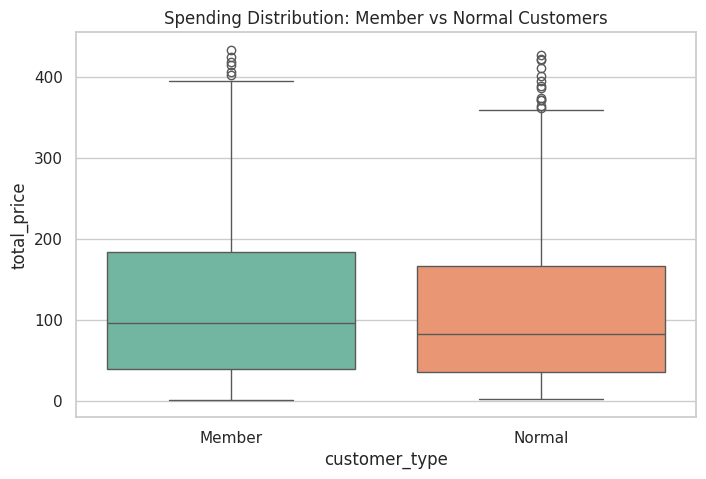

In [6]:
# Compare Total Revenue: Member vs Normal Customers
loyalty_analysis = df.groupby('customer_type')['total_price'].sum()

print("--- Revenue by Customer Loyalty ---")
print(loyalty_analysis)

# Plotting the result
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='customer_type', y='total_price', palette='Set2')
plt.title('Spending Distribution: Member vs Normal Customers')
plt.show()